# 01 — EDA and documentation verification

This notebook has one job: check that `docs/dataset_field_documentation.md`
still describes the file sitting in `datasets/`. Every headline number in that
document is recomputed here and compared automatically.

It is not exploratory decoration. If a cell below reports FAIL, either the
dataset was replaced or the documentation is wrong, and no modelling result
produced against it can be trusted.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data import loader

# Palette: categorical slots 1-2 for non-fraud/fraud, diverging blue-red for
# correlation sign. Validated for CVD separation and contrast on a light surface.
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.size": 9,
    "figure.dpi": 110,
})

print(f"python {sys.version.split()[0]}  pandas {pd.__version__}  numpy {np.__version__}")

python 3.14.3  pandas 3.0.5  numpy 2.5.1


## Load

The documented statistics were computed on the raw file *including* its 1,081
duplicate rows, so verification loads it that way. The deduplicated view — the
one every model actually sees — is compared against it afterwards.

In [2]:
raw, raw_report = loader.load_raw(drop_duplicates=False, compute_hash=False)
clean, clean_report = loader.load_raw(drop_duplicates=True, compute_hash=False)

print(f"raw    {raw_report.n_rows:>8,} rows  {raw_report.n_fraud:>4} fraud")
print(f"clean  {clean_report.n_rows:>8,} rows  {clean_report.n_fraud:>4} fraud"
      f"   (-{raw_report.n_rows - clean_report.n_rows:,} duplicates,"
      f" {raw_report.n_fraud - clean_report.n_fraud} of them fraud)")

raw     284,807 rows   492 fraud
clean   283,726 rows   473 fraud   (-1,081 duplicates, 19 of them fraud)


## Verification against the documentation

In [3]:
fraud = raw[raw[config.TARGET_COLUMN] == 1]
legit = raw[raw[config.TARGET_COLUMN] == 0]

checks = [
    ("rows",                    len(raw),                                    284_807,   0),
    ("fraud cases",             int(raw[config.TARGET_COLUMN].sum()),        492,       0),
    ("duplicate rows",          int(raw.duplicated().sum()),                 1_081,     0),
    ("null cells",              int(raw.isnull().sum().sum()),               0,         0),
    ("fraud rate %",            raw[config.TARGET_COLUMN].mean() * 100,      0.1727,    0.0001),
    ("Time max (s)",            raw["Time"].max(),                           172_792,   0),
    ("Time mean (s)",           raw["Time"].mean(),                          94_813.86, 0.01),
    ("Time median (s)",         raw["Time"].median(),                        84_692.0,  0.01),
    ("Amount mean",             raw["Amount"].mean(),                        88.35,     0.01),
    ("Amount median",           raw["Amount"].median(),                      22.00,     0.01),
    ("Amount std",              raw["Amount"].std(),                         250.12,    0.01),
    ("Amount max",              raw["Amount"].max(),                         25_691.16, 0.01),
    ("Amount == 0 count",       int((raw["Amount"] == 0).sum()),             1_825,     0),
    ("Amount skew",             raw["Amount"].skew(),                        16.98,     0.01),
    ("fraud Amount mean",       fraud["Amount"].mean(),                      122.21,    0.01),
    ("fraud Amount median",     fraud["Amount"].median(),                    9.25,      0.01),
    ("non-fraud Amount mean",   legit["Amount"].mean(),                      88.29,     0.01),
    ("non-fraud Amount median", legit["Amount"].median(),                    22.00,     0.01),
]

rows = []
for name, actual, expected, tol in checks:
    ok = abs(float(actual) - float(expected)) <= tol
    rows.append({
        "check": name,
        "documented": expected,
        "computed": round(float(actual), 4),
        "status": "PASS" if ok else "FAIL",
    })

verification = pd.DataFrame(rows)
n_failed = int((verification["status"] == "FAIL").sum())
print(verification.to_string(index=False))
print(f"\n{len(verification) - n_failed}/{len(verification)} checks pass")
assert n_failed == 0, f"{n_failed} documented statistics no longer match the data"

                  check  documented    computed status
                   rows 284807.0000 284807.0000   PASS
            fraud cases    492.0000    492.0000   PASS
         duplicate rows   1081.0000   1081.0000   PASS
             null cells      0.0000      0.0000   PASS
           fraud rate %      0.1727      0.1727   PASS
           Time max (s) 172792.0000 172792.0000   PASS
          Time mean (s)  94813.8600  94813.8596   PASS
        Time median (s)  84692.0000  84692.0000   PASS
            Amount mean     88.3500     88.3496   PASS
          Amount median     22.0000     22.0000   PASS
             Amount std    250.1200    250.1201   PASS
             Amount max  25691.1600  25691.1600   PASS
      Amount == 0 count   1825.0000   1825.0000   PASS
            Amount skew     16.9800     16.9777   PASS
      fraud Amount mean    122.2100    122.2113   PASS
    fraud Amount median      9.2500      9.2500   PASS
  non-fraud Amount mean     88.2900     88.2910   PASS
non-fraud 

## Time

`Time` is seconds elapsed since the first transaction, not a wall-clock hour,
so "hour 0" is whatever hour collection began. The two-day day/night cycle is
clearly visible in volume; fraud does not follow it.

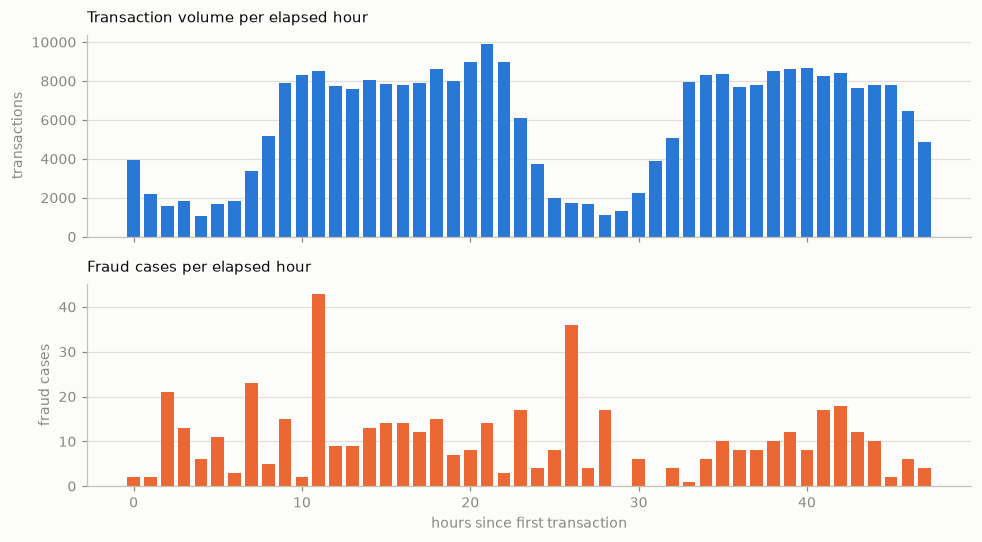

volume trough at hour 4, peak at hour 21
most fraud in hour 11 (43 cases); fraud appears in 46 of 48 hours


In [4]:
hourly = raw.assign(hour=(raw["Time"] // 3600).astype(int)).groupby("hour")
volume = hourly.size()
fraud_count = hourly[config.TARGET_COLUMN].sum()

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                                        height_ratios=[1, 1])

ax_top.bar(volume.index, volume.values, color=BLUE, width=0.75)
ax_top.set_ylabel("transactions")
ax_top.set_title("Transaction volume per elapsed hour", loc="left",
                 fontsize=10, color=INK, pad=8)

ax_bottom.bar(fraud_count.index, fraud_count.values, color=ORANGE, width=0.75)
ax_bottom.set_ylabel("fraud cases")
ax_bottom.set_xlabel("hours since first transaction")
ax_bottom.set_title("Fraud cases per elapsed hour", loc="left",
                    fontsize=10, color=INK, pad=8)

for ax in (ax_top, ax_bottom):
    ax.grid(axis="y", linewidth=0.8)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

peak = int(fraud_count.idxmax())
print(f"volume trough at hour {int(volume.idxmin())}, peak at hour {int(volume.idxmax())}")
print(f"most fraud in hour {peak} ({int(fraud_count.max())} cases); "
      f"fraud appears in {int((fraud_count > 0).sum())} of {len(fraud_count)} hours")

## Amount

The documentation flags something counterintuitive: fraud has a **higher mean**
($122.21 vs $88.29) but a **lower median** ($9.25 vs $22.00). That combination
is the signature of a bimodal distribution — many tiny card-testing charges
plus a few large cash-outs — and it is why a single amount threshold cannot
separate the classes.

fraud     mean $ 122.21   median $  9.25
non-fraud mean $  88.29   median $ 22.00

fraud under $1:  13.8% of fraud vs 5.9% of non-fraud
fraud over $500: 7.1% of fraud vs 3.2% of non-fraud

excluded from the plot: 1,798 non-fraud and 27 fraud transactions of exactly $0


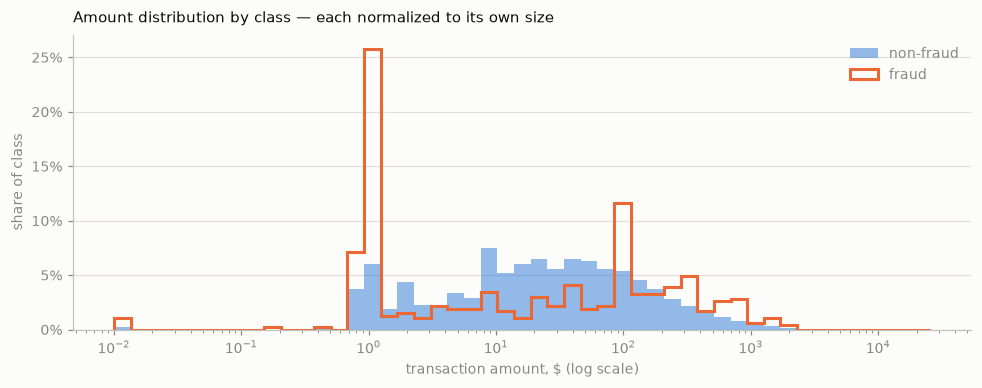

In [5]:
print(f"fraud     mean ${fraud['Amount'].mean():7.2f}   median ${fraud['Amount'].median():6.2f}")
print(f"non-fraud mean ${legit['Amount'].mean():7.2f}   median ${legit['Amount'].median():6.2f}")
print(f"\nfraud under $1:  {(fraud['Amount'] < 1).mean():.1%} of fraud "
      f"vs {(legit['Amount'] < 1).mean():.1%} of non-fraud")
print(f"fraud over $500: {(fraud['Amount'] > 500).mean():.1%} of fraud "
      f"vs {(legit['Amount'] > 500).mean():.1%} of non-fraud")

# Zero amounts cannot be placed on a log axis; they are counted separately
# rather than nudged to 0.01, which would invent a spike at the low end.
legit_amount = legit["Amount"][legit["Amount"] > 0]
fraud_amount = fraud["Amount"][fraud["Amount"] > 0]
print(f"\nexcluded from the plot: {(legit['Amount'] == 0).sum():,} non-fraud "
      f"and {(fraud['Amount'] == 0).sum()} fraud transactions of exactly $0")

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(
    np.log10(min(legit_amount.min(), fraud_amount.min())),
    np.log10(raw["Amount"].max()),
    50,
)

# Each class is normalized by its own size, so the two shapes are comparable
# despite the 578:1 imbalance. Bin heights are shares, not densities — density
# would be distorted here because log-spaced bins have unequal linear widths.
ax.hist(legit_amount, bins=bins, weights=np.full(len(legit_amount), 1 / len(legit_amount)),
        color=BLUE, alpha=0.5, linewidth=0, label="non-fraud")
ax.hist(fraud_amount, bins=bins, weights=np.full(len(fraud_amount), 1 / len(fraud_amount)),
        histtype="step", color=ORANGE, linewidth=2, label="fraud")

ax.set_xscale("log")
ax.set_xlabel("transaction amount, $ (log scale)")
ax.set_ylabel("share of class")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Amount distribution by class — each normalized to its own size",
             loc="left", fontsize=10, color=INK, pad=8)
ax.legend(frameon=False, labelcolor=MUTED)
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

## Which PCA components carry the signal

V1–V28 are anonymized principal components, so none of them has a business
meaning. Correlation with the label still shows which ones a model will lean
on — and confirms the documentation's claim that V17, V14 and V12 lead.

  PASS  V17  documented -0.3265  computed -0.3265
  PASS  V14  documented -0.3025  computed -0.3025
  PASS  V12  documented -0.2606  computed -0.2606
  PASS  V11  documented +0.1549  computed +0.1549
  PASS  V4   documented +0.1334  computed +0.1334


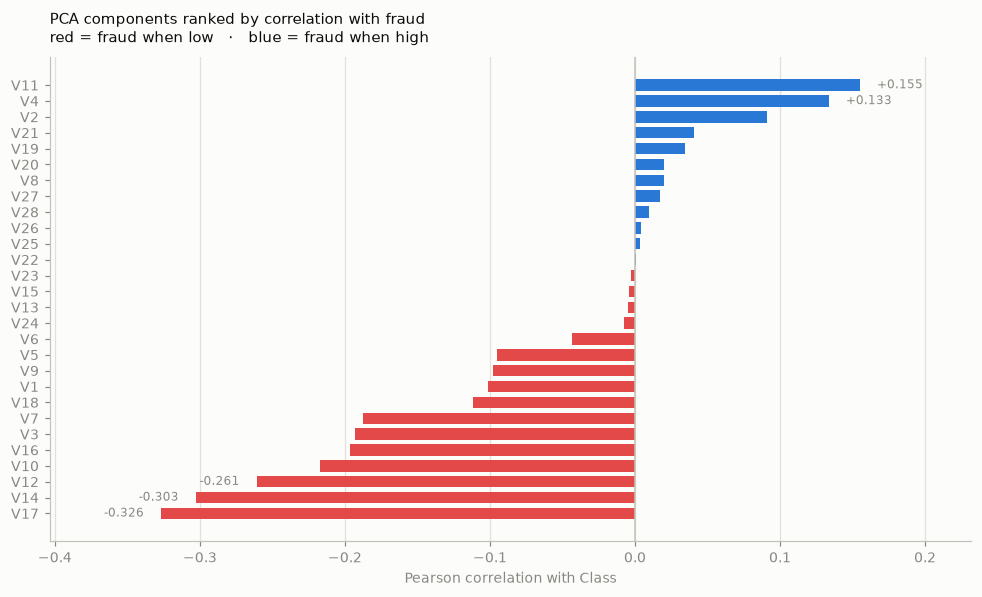

In [6]:
correlations = (
    raw[config.PCA_COLUMNS + [config.TARGET_COLUMN]]
    .corr()[config.TARGET_COLUMN]
    .drop(config.TARGET_COLUMN)
    .sort_values()
)

documented_top = {"V17": -0.3265, "V14": -0.3025, "V12": -0.2606,
                  "V11": 0.1549, "V4": 0.1334}
for feature, expected in documented_top.items():
    actual = correlations[feature]
    status = "PASS" if abs(actual - expected) < 0.001 else "FAIL"
    print(f"  {status}  {feature:4s} documented {expected:+.4f}  computed {actual:+.4f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [RED if v < 0 else BLUE for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, height=0.72)

ax.axvline(0, color="#c3c2b7", linewidth=1)
# Room at both ends for the direct labels, which otherwise collide with the
# tick labels on the left and run off the axis on the right.
span = correlations.max() - correlations.min()
ax.set_xlim(correlations.min() - 0.16 * span, correlations.max() + 0.16 * span)
ax.set_xlabel("Pearson correlation with Class")
ax.set_title("PCA components ranked by correlation with fraud\n"
             "red = fraud when low   ·   blue = fraud when high",
             loc="left", fontsize=10, color=INK, pad=10)
ax.grid(axis="x", linewidth=0.8)
ax.set_axisbelow(True)

# Direct-label only the components strong enough to matter.
for feature in ("V17", "V14", "V12", "V11", "V4"):
    value = correlations[feature]
    position = list(correlations.index).index(feature)
    ax.text(value + (-0.012 if value < 0 else 0.012), position, f"{value:+.3f}",
            va="center", ha="right" if value < 0 else "left",
            fontsize=8, color=MUTED)

fig.tight_layout()
plt.show()

## What the splits look like

Read back from the manifest written by `scripts/build_splits.py` rather than
recomputed, so this reflects the splits models are actually trained on.

In [7]:
manifest = loader.read_manifest()

print(f"source sha256      {manifest['source']['sha256'][:32]}...")
print(f"duplicates dropped {manifest['source']['n_duplicates_dropped']:,}")
print(f"dev/holdout cut    Time = {manifest['dev_holdout_cut_time']:,.0f}s\n")

split_table = pd.DataFrame([
    {"split": name, "rows": s["n_rows"], "fraud": s["n_fraud"],
     "fraud rate %": round(s["fraud_rate"] * 100, 4),
     "t_start": int(s["time_min"]), "t_end": int(s["time_max"])}
    for name, s in manifest["splits"].items()
])
print(split_table.to_string(index=False))

fold_table = pd.DataFrame([
    {"fold": f["index"],
     "train rows": f["train"]["n_rows"], "train fraud": f["train"]["n_fraud"],
     "val rows": f["val"]["n_rows"], "val fraud": f["val"]["n_fraud"]}
    for f in manifest["folds"]
])
print("\nexpanding-window folds over dev:")
print(fold_table.to_string(index=False))

total_val_fraud = int(fold_table["val fraud"].sum())
holdout_fraud = manifest["splits"]["holdout"]["n_fraud"]
print(f"\nmodel selection sees {total_val_fraud} fraud cases across "
      f"{len(fold_table)} folds; the locked holdout holds {holdout_fraud}.")

source sha256      76274b691b16a6c49d3f159c883398e0...
duplicates dropped 1,081
dev/holdout cut    Time = 145,234s

  split   rows  fraud  fraud rate %  t_start  t_end
    dev 226982    399        0.1758        0 145234
holdout  56744     74        0.1304   145235 172792

expanding-window folds over dev:
 fold  train rows  train fraud  val rows  val fraud
    0       45397          142     45397         69
    1       90794          211     45396         47
    2      136190          258     45396         89
    3      181586          347     45396         52

model selection sees 257 fraud cases across 4 folds; the locked holdout holds 74.


## What this means for Phase 1

Three constraints follow directly from the numbers above, and they shape every
experiment that comes next:

1. **The positive class is tiny even in aggregate.** Model selection runs on
   roughly 250 fraud cases spread across four folds; the holdout holds about
   75. AUPRC on that many positives carries a confidence interval several
   tenths wide, so a single point estimate is not evidence. Use
   `metrics.compare_auprc` — the paired bootstrap — for every model comparison.

2. **Fraud does not follow the volume cycle.** The busiest hours are not the
   most fraudulent ones, so raw time-of-day is a weak feature here. Velocity
   and inter-arrival features are more promising, but neither can be built per
   customer: the dataset has no entity IDs at all.

3. **Amount is bimodal within the fraud class.** Cost-sensitive weighting by
   amount, which the Kaggle notes recommend, will pull the model toward the
   large cash-out mode and away from the card-testing mode. If both matter,
   they should be evaluated separately rather than averaged into one metric.